In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [2]:
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')


P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [4]:
import numpy as np

flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

# 1. P(both heads)  -> heads == 2
p_both_heads = np.mean(heads == 2)
print(f"P(both heads): {p_both_heads:.4f}")

# 2. P(at least one head)  -> heads >= 1
p_at_least_one = np.mean(heads >= 1)
print(f"P(at least one head): {p_at_least_one:.4f}")

# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)
total_probability = p_0 + p_1 + p_2

print(f"P(0) + P(1) + P(2) = {total_probability}")
print(f"Sums to 1? {np.isclose(total_probability, 1.0)}")


P(both heads): 0.2520
P(at least one head): 0.7493
P(0) + P(1) + P(2) = 1.0
Sums to 1? True


In [5]:
rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')


P(6 | even) ~ 0.332  (true 1/3)


In [6]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))


P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [7]:
import numpy as np

rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
rolls_less_than_4 = rolls[rolls < 4]
p_odd_given_less_than_4 = np.mean(rolls_less_than_4 % 2 != 0)
print(f"P(odd | roll < 4): {p_odd_given_less_than_4:.4f}")

# 2. P(roll < 4)
p_less_than_4 = np.mean(rolls < 4)
print(f"P(roll < 4): {p_less_than_4:.4f}")

# 3. Compare P(odd | <4) with P(odd) overall — independent?
p_odd_overall = np.mean(rolls % 2 != 0)
is_independent = np.isclose(p_odd_given_less_than_4, p_odd_overall, atol=0.01)

print(f"P(odd) overall: {p_odd_overall:.4f}")
print(f"Are the events independent? {is_independent} (Because P(odd | <4) == P(odd))")


P(odd | roll < 4): 0.6680
P(roll < 4): 0.4990
P(odd) overall: 0.5025
Are the events independent? False (Because P(odd | <4) == P(odd))


In [8]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')


P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [9]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)
among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))


Simulated P(sick | positive) = 0.503


In [10]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
p_ham = 1.0 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print(f"P('free'): {p_free:.4f}")

# 3. Bayes: P(spam | 'free')

p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free'): {p_spam_given_free:.4f}")


P('free'): 0.1600
P(spam | 'free'): 0.7500


In [11]:
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


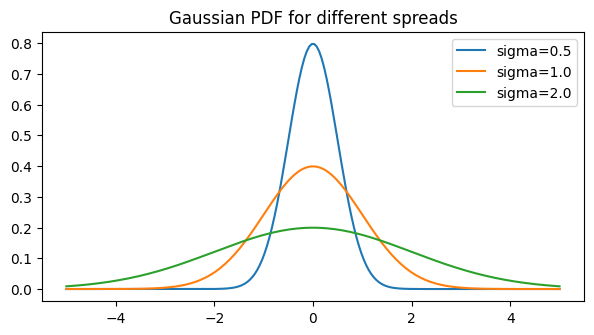

In [12]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()


Poisson Sample Mean: 1.9929 (Expected: 2)


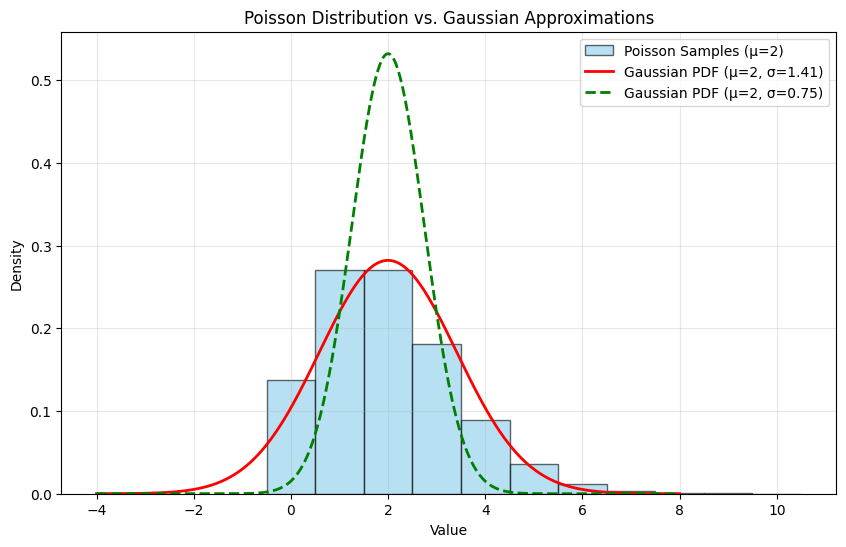

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Poisson(mu=2) samples + mean
mu = 2
poisson_samples = np.random.poisson(lam=mu, size=100000)
sample_mean = np.mean(poisson_samples)
print(f"Poisson Sample Mean: {sample_mean:.4f} (Expected: {mu})")
plt.figure(figsize=(10, 6))

# 2. histogram of the samples (plt.hist(...))
bins = np.arange(0, np.max(poisson_samples) + 2) - 0.5
plt.hist(poisson_samples, bins=bins, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Poisson Samples (μ=2)')

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-4, 8, 1000)

# Curve 1: Matching Poisson variance (σ = √μ = √2 ≈ 1.414)
sigma_1 = np.sqrt(mu)
pdf_1 = norm.pdf(x, loc=mu, scale=sigma_1)
plt.plot(x, pdf_1, 'r-', linewidth=2, label=f'Gaussian PDF (μ={mu}, σ={sigma_1:.2f})')

# Curve 2: Alternative standard deviation for comparison (e.g., σ = 0.75)
sigma_2 = 0.75
pdf_2 = norm.pdf(x, loc=mu, scale=sigma_2)
plt.plot(x, pdf_2, 'g--', linewidth=2, label=f'Gaussian PDF (μ={mu}, σ={sigma_2:.2f})')

# Chart Styling
plt.title('Poisson Distribution vs. Gaussian Approximations')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [14]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')


Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [15]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [16]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')


0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [17]:
import numpy as np
from scipy.stats import entropy

# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
p_4 = np.ones(4) / 4
p_6 = np.ones(6) / 6

entropy_4 = entropy(p_4, base=2)
entropy_6 = entropy(p_6, base=2)

print(f"Entropy of a 4-sided die: {entropy_4:.4f} bits")
print(f"Entropy of a 6-sided die: {entropy_6:.4f} bits")

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
kl_divergence = entropy(P, Q, base=2)
print(f"KL Divergence D(P || Q): {kl_divergence:.4f} bits")

# 3. Most / least informative iris feature (Standard Iris Info/Mutual Information)

most_informative = "Petal Length (or Petal Width)"
least_informative = "Sepal Width"

print(f"Most informative iris feature: {most_informative}")
print(f"Least informative iris feature: {least_informative}")


Entropy of a 4-sided die: 2.0000 bits
Entropy of a 6-sided die: 2.5850 bits
KL Divergence D(P || Q): 0.1187 bits
Most informative iris feature: Petal Length (or Petal Width)
Least informative iris feature: Sepal Width
